# 🔧 Equipment Maintenance Intelligent Decision System
### Knowledge Engineering Final Project — Master's Program

> **Problem:** Industrial equipment failures cost manufacturers an average of **$260,000 per hour** in unplanned downtime.  
> **Solution:** An AI-powered decision system that monitors 5 machines in real time, scores risk across 5 sensor dimensions, detects anomalies automatically, and uses Claude (LLM) to generate plain-English maintenance recommendations — before failures happen.

| | |
|---|---|
| **Target users** | Maintenance engineers & plant managers |
| **Decision type** | Predictive maintenance scheduling |
| **LLM role** | Root cause analysis + action recommendations |
| **Tech stack** | Python · Jupyter · pandas · sklearn · matplotlib · ipywidgets · Anthropic API |

---
| Section | Content |
|---|---|
| 1 | Setup & Data Simulation |
| 2 | Data Input (Widget UI) |
| 3 | Analysis & Decision Engine |
| 4 | Result Display & Visualization |
| 5 | LLM Suggestion Engine (Claude API) |
| 6 | Parameter Interaction Dashboard |
| 7 | 📊 Presentation Summary |


## Section 1 — Setup & Data Simulation

In [1]:
# Uncomment to install dependencies (run once)
# !pip install pandas numpy matplotlib scikit-learn ipywidgets anthropic

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from sklearn.ensemble import IsolationForest
try:
    import anthropic           # only needed for the OPTIONAL online Claude path
except ImportError:
    anthropic = None         # offline mode needs no network and no API key
import warnings
import os

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.facecolor'] = '#f8f9fa'
plt.rcParams['axes.facecolor'] = '#ffffff'
plt.rcParams['font.family'] = 'DejaVu Sans'

print('✅ All libraries loaded.')

✅ All libraries loaded.


In [3]:
# ─────────────────────────────────────────────
# GLOBAL CONFIG
# ─────────────────────────────────────────────
EQUIPMENT_IDS    = ['M-001', 'M-002', 'M-003', 'M-004', 'M-005']
DAYS             = 30
READINGS_PER_DAY = 3
RANDOM_SEED      = 42
np.random.seed(RANDOM_SEED)

RISK_COLORS = {
    'Low':      '#2ecc71',
    'Medium':   '#f39c12',
    'High':     '#e67e22',
    'Critical': '#e74c3c'
}

# ── Anthropic API Key ──────────────────────────
# Replace with your actual key or set as env variable
# ── Recommendation Engine Mode ─────────────
# OFFLINE (default): built-in maintenance expert system — no API key, no internet,
#   so it runs ANYWHERE including mainland China and offline during a presentation.
# ONLINE (optional): set USE_LLM_API = True AND a real ANTHROPIC_API_KEY to use Claude.
USE_LLM_API       = False
ANTHROPIC_API_KEY = os.environ.get('ANTHROPIC_API_KEY', 'YOUR_API_KEY_HERE')

In [4]:
# ─────────────────────────────────────────────
# RISK SCORING ENGINE
# ─────────────────────────────────────────────
def compute_risk_score(temp, vibration, runtime_hours, pressure, error_count):
    """
    Rule-based risk scoring. Returns 0 (healthy) to 100 (critical).
    Each sensor contributes a weighted sub-score based on thresholds.
    """
    score = 0

    # Temperature (°C) — max 35 pts
    if temp > 95:         score += 35
    elif temp > 85:       score += 20
    elif temp > 75:       score += 10

    # Vibration (mm/s) — max 25 pts
    if vibration > 6.0:   score += 25
    elif vibration > 4.5: score += 15
    elif vibration > 3.0: score += 8

    # Runtime hours — max 20 pts
    if runtime_hours > 500:   score += 20
    elif runtime_hours > 350: score += 12
    elif runtime_hours > 200: score += 5

    # Pressure (bar) — max 12 pts
    if pressure > 9.0:    score += 12
    elif pressure > 7.5:  score += 6

    # Error count (24h) — max 8 pts
    if error_count > 8:   score += 8
    elif error_count > 4: score += 4

    return min(score, 100)


def score_to_level(score):
    if score >= 75:  return 'Critical'
    elif score >= 50: return 'High'
    elif score >= 25: return 'Medium'
    else:            return 'Low'


print('✅ Risk engine defined.')

✅ Risk engine defined.


In [5]:
# ---------------------------------------------------
# DATA SIMULATION  (dramatic demo profiles)
# ---------------------------------------------------
def simulate_equipment_data():
    # Five machines with distinct, visually dramatic failure patterns
    records = []
    timestamps = pd.date_range('2024-05-01', periods=DAYS * READINGS_PER_DAY, freq='8h')

    profiles = {
        'M-001': dict(label='Healthy',            temp_base=62, temp_drift=0.0, vib_base=1.8, runtime_base=40,  pressure_base=5.2, error_base=0.2),
        'M-002': dict(label='Overheating',         temp_base=74, temp_drift=0.9, vib_base=2.4, runtime_base=90,  pressure_base=5.8, error_base=0.8),
        'M-003': dict(label='Bearing Failure',     temp_base=71, temp_drift=0.2, vib_base=3.5, runtime_base=180, pressure_base=6.3, error_base=1.5),
        'M-004': dict(label='Overdue Maintenance', temp_base=83, temp_drift=0.3, vib_base=4.0, runtime_base=460, pressure_base=7.8, error_base=4.0),
        'M-005': dict(label='Cascading Failure',   temp_base=78, temp_drift=0.6, vib_base=4.5, runtime_base=310, pressure_base=8.2, error_base=7.0),
    }

    for eq_id, p in profiles.items():
        for i, ts in enumerate(timestamps):
            day  = i // READINGS_PER_DAY
            frac = day / DAYS

            temp = p['temp_base'] + p['temp_drift'] * day + np.random.normal(0, 1.5)

            # M-003: bearing vibration spikes in final 10 days
            vib_extra = (day - 20) * 0.28 if (eq_id == 'M-003' and day >= 20) else 0
            vibration = max(0, p['vib_base'] + vib_extra + np.random.normal(0, 0.25))

            # M-005: error rate accelerates as machine degrades
            err_rate = p['error_base'] * (1 + frac * 2.0) if eq_id == 'M-005' else p['error_base']

            runtime  = int(p['runtime_base'] + day * 8 + np.random.randint(0, 3))
            pressure = max(0, p['pressure_base'] + np.random.normal(0, 0.3))
            errors   = max(0, int(np.random.poisson(err_rate)))
            score    = compute_risk_score(temp, vibration, runtime, pressure, errors)

            records.append({
                'equipment_id':  eq_id,
                'profile':       p['label'],
                'timestamp':     ts,
                'temperature':   round(temp, 1),
                'vibration':     round(vibration, 2),
                'runtime_hours': runtime,
                'pressure':      round(pressure, 1),
                'error_count':   errors,
                'risk_score':    score,
                'risk_level':    score_to_level(score)
            })

    df = pd.DataFrame(records)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    return df


df = simulate_equipment_data()

features = ['temperature', 'vibration', 'runtime_hours', 'pressure', 'error_count']
iso = IsolationForest(contamination=0.07, random_state=RANDOM_SEED)
df['anomaly']    = iso.fit_predict(df[features])
df['is_anomaly'] = df['anomaly'] == -1

os.makedirs('data', exist_ok=True)
df.to_csv('data/equipment_data.csv', index=False)

print(f'Dataset: {len(df)} readings across {df["equipment_id"].nunique()} machines')
print(f'Anomalies detected: {df["is_anomaly"].sum()}')
display(df.head(6))


Dataset: 450 readings across 5 machines
Anomalies detected: 32


,equipment_id,profile,timestamp,temperature,vibration,runtime_hours,pressure,error_count,risk_score,risk_level,anomaly,is_anomaly
0,M-001,Healthy,2024-05-01 00:00:00,62.7,1.77,42,5.3,0,0,Low,1,False
1,M-001,Healthy,2024-05-01 08:00:00,64.1,1.78,40,4.9,0,0,Low,1,False
2,M-001,Healthy,2024-05-01 16:00:00,61.1,1.67,40,5.6,0,0,Low,1,False
3,M-001,Healthy,2024-05-02 00:00:00,64.3,1.81,50,5.1,0,0,Low,1,False
4,M-001,Healthy,2024-05-02 08:00:00,60.6,1.45,49,5.3,0,0,Low,1,False
5,M-001,Healthy,2024-05-02 16:00:00,60.8,1.79,48,5.3,0,0,Low,1,False


---
## Section 2 — Data Input (Widget UI)
Manually enter live sensor readings for any machine using interactive sliders.

In [6]:
# ─────────────────────────────────────────────
# LIVE DATA INPUT WIDGET
# ─────────────────────────────────────────────
style  = {'description_width': '160px'}
layout = widgets.Layout(width='420px')

w_machine  = widgets.Dropdown(options=EQUIPMENT_IDS, description='Equipment ID:', style=style, layout=layout)
w_temp     = widgets.FloatSlider(value=75, min=30, max=120, step=0.5,  description='Temperature (°C):',  style=style, layout=layout, readout_format='.1f')
w_vib      = widgets.FloatSlider(value=3.0, min=0, max=10,  step=0.1, description='Vibration (mm/s):',  style=style, layout=layout, readout_format='.1f')
w_runtime  = widgets.IntSlider(value=200, min=0, max=800, step=10,     description='Runtime Hours:',     style=style, layout=layout)
w_pressure = widgets.FloatSlider(value=6.0, min=0, max=12, step=0.1,  description='Pressure (bar):',    style=style, layout=layout, readout_format='.1f')
w_errors   = widgets.IntSlider(value=2, min=0, max=20,                 description='Errors (24h):',      style=style, layout=layout)
btn_analyze = widgets.Button(description='▶ Analyze Reading', button_style='primary',
                              layout=widgets.Layout(width='200px', margin='12px 0 0 160px'))
out_input   = widgets.Output()

# Store the last live reading globally
live_reading = {}

def on_analyze(b):
    global live_reading
    live_reading = {
        'equipment_id':  w_machine.value,
        'temperature':   w_temp.value,
        'vibration':     w_vib.value,
        'runtime_hours': w_runtime.value,
        'pressure':      w_pressure.value,
        'error_count':   w_errors.value,
    }
    score = compute_risk_score(**{k: v for k, v in live_reading.items() if k != 'equipment_id'})
    level = score_to_level(score)
    live_reading['risk_score'] = score
    live_reading['risk_level'] = level

    color = RISK_COLORS[level]
    with out_input:
        clear_output()
        display(HTML(f"""
        <div style="border-left: 5px solid {color}; background:#f8f9fa; padding:12px 16px; border-radius:4px; margin-top:8px; font-family:monospace;">
            <b>Live Reading — {live_reading['equipment_id']}</b><br>
            Temp: {live_reading['temperature']}°C &nbsp;|
            Vibration: {live_reading['vibration']} mm/s &nbsp;|
            Runtime: {live_reading['runtime_hours']}h &nbsp;|
            Pressure: {live_reading['pressure']} bar &nbsp;|
            Errors: {live_reading['error_count']}<br><br>
            <span style="font-size:18px; color:{color};"><b>Risk Score: {score}/100 — {level}</b></span>
        </div>
        """))
        print('\n✅ Reading saved. Scroll to Section 3 or Section 5 to analyze further.')

btn_analyze.on_click(on_analyze)

panel = widgets.VBox([
    widgets.HTML('<h3 style="margin:0 0 8px">📥 Live Sensor Input</h3>'),
    w_machine, w_temp, w_vib, w_runtime, w_pressure, w_errors,
    btn_analyze,
    out_input
])

display(panel)

In [7]:
# ─────────────────────────────────────────────
# OPTIONAL: Upload your own CSV
# ─────────────────────────────────────────────
upload_widget = widgets.FileUpload(accept='.csv', multiple=False)
out_upload    = widgets.Output()

def on_upload(change):
    global df
    with out_upload:
        clear_output()
        for name, content in upload_widget.value.items():
            import io
            df_uploaded = pd.read_csv(io.BytesIO(content['content']))
            print(f'✅ Uploaded: {name} — {len(df_uploaded)} rows, {len(df_uploaded.columns)} columns')
            display(df_uploaded.head(5))
            # Merge with existing if columns match
            required = {'equipment_id','temperature','vibration','runtime_hours','pressure','error_count'}
            if required.issubset(set(df_uploaded.columns)):
                df_uploaded['risk_score'] = df_uploaded.apply(
                    lambda r: compute_risk_score(r.temperature, r.vibration, r.runtime_hours, r.pressure, r.error_count), axis=1)
                df_uploaded['risk_level'] = df_uploaded['risk_score'].apply(score_to_level)
                df = df_uploaded
                print('✅ Dataset replaced with uploaded data.')
            else:
                print(f'⚠️  Missing required columns: {required - set(df_uploaded.columns)}')

upload_widget.observe(on_upload, names='value')

display(widgets.VBox([
    widgets.HTML('<h3 style="margin:0 0 8px">📂 Upload CSV (optional)</h3>'),
    upload_widget,
    out_upload
]))

---
## Section 3 — Analysis & Decision Engine
Compute risk summaries and detect which machines need immediate attention.

In [8]:
# ─────────────────────────────────────────────
# FLEET SUMMARY TABLE
# ─────────────────────────────────────────────
def fleet_summary(dataframe):
    """Compute latest reading stats per machine."""
    latest = dataframe.sort_values('timestamp').groupby('equipment_id').last().reset_index()
    avg    = dataframe.groupby('equipment_id')['risk_score'].mean().reset_index()
    avg.columns = ['equipment_id', 'avg_risk_score']
    summary = latest.merge(avg, on='equipment_id')
    summary['avg_risk_score'] = summary['avg_risk_score'].round(1)
    return summary[['equipment_id', 'profile', 'risk_score', 'risk_level', 'avg_risk_score',
                     'temperature', 'vibration', 'runtime_hours', 'pressure', 'error_count']]


summary = fleet_summary(df)

# Color-code by risk level
def highlight_risk(row):
    colors = {'Low': 'background-color:#d5f5e3', 'Medium': 'background-color:#fdebd0',
              'High': 'background-color:#fad7a0', 'Critical': 'background-color:#f5b7b1'}
    return [colors.get(row['risk_level'], '')] * len(row)

display(HTML('<h3>🏭 Fleet Status — Latest Readings</h3>'))
display(summary.style.apply(highlight_risk, axis=1).format({
    'risk_score': '{:.0f}', 'avg_risk_score': '{:.1f}',
    'temperature': '{:.1f}', 'vibration': '{:.2f}', 'pressure': '{:.1f}'
}))

,equipment_id,profile,risk_score,risk_level,avg_risk_score,temperature,vibration,runtime_hours,pressure,error_count
0,M-001,Healthy,5,Low,1.6,63.0,1.84,272,5.5,0
1,M-002,Overheating,40,Medium,21.0,101.4,2.58,324,5.8,0
2,M-003,Bearing Failure,37,Medium,19.0,77.6,5.30,414,6.4,1
3,M-004,Overdue Maintenance,54,High,51.0,92.6,4.16,693,8.1,2
4,M-005,Cascading Failure,69,High,54.7,94.7,4.55,544,8.3,20


In [9]:
# ─────────────────────────────────────────────
# DECISION RULES ENGINE
# ─────────────────────────────────────────────
def generate_decision(row):
    """Rule-based decision for a given machine reading."""
    actions = []
    if row['risk_level'] == 'Critical':
        actions.append('🔴 IMMEDIATE SHUTDOWN REQUIRED')
    if row['temperature'] > 90:
        actions.append('🌡️  Check cooling system / reduce load')
    if row['vibration'] > 5:
        actions.append('📳 Inspect bearings and mounting bolts')
    if row['runtime_hours'] > 400:
        actions.append('🔧 Schedule full maintenance (overdue)')
    if row['pressure'] > 8:
        actions.append('⚠️  Check pressure relief valves')
    if row['error_count'] > 5:
        actions.append('💻 Review error logs — possible sensor fault')
    if not actions:
        actions.append('✅ No immediate action required')
    return actions


print('=== Decision Engine Output ===')
for _, row in summary.iterrows():
    color = RISK_COLORS[row['risk_level']]
    display(HTML(f"""
    <div style="border-left:5px solid {color}; padding:8px 14px; margin:6px 0; background:#fafafa; border-radius:3px;">
        <b>{row['equipment_id']} — {row['profile']}</b> &nbsp;
        <span style="color:{color};">● {row['risk_level']} ({int(row['risk_score'])}/100)</span><br>
        {'<br>'.join(generate_decision(row))}
    </div>
    """))

=== Decision Engine Output ===


In [10]:
# ─────────────────────────────────────────────
# ANOMALY SUMMARY
# ─────────────────────────────────────────────
anomalies = df[df['is_anomaly']]
display(HTML(f'<h3>🚨 Anomalies Detected: {len(anomalies)} readings</h3>'))
display(anomalies[['equipment_id', 'timestamp', 'temperature', 'vibration',
                    'runtime_hours', 'pressure', 'error_count', 'risk_score', 'risk_level']]
        .sort_values('risk_score', ascending=False).head(10)
        .reset_index(drop=True))

,equipment_id,timestamp,temperature,vibration,runtime_hours,pressure,error_count,risk_score,risk_level
0,M-005,2024-05-30 00:00:00,97.7,4.69,543,8.4,24,84,Critical
1,M-005,2024-05-29 16:00:00,95.3,4.58,534,8.3,21,84,Critical
2,M-005,2024-05-27 08:00:00,95.6,4.68,518,7.9,22,84,Critical
3,M-005,2024-05-30 08:00:00,96.4,4.27,544,8.1,27,77,Critical
4,M-005,2024-05-28 16:00:00,95.6,4.45,526,8.0,29,77,Critical
5,M-005,2024-05-29 08:00:00,94.5,4.72,536,8.6,28,69,High
6,M-005,2024-05-26 08:00:00,93.8,5.05,510,8.2,27,69,High
7,M-005,2024-05-18 16:00:00,88.3,4.86,447,8.4,29,61,High
8,M-004,2024-05-29 08:00:00,92.9,4.49,686,7.7,8,58,High
9,M-004,2024-05-28 16:00:00,93.0,3.47,677,8.7,7,58,High


---
## Section 4 — Result Display & Visualization

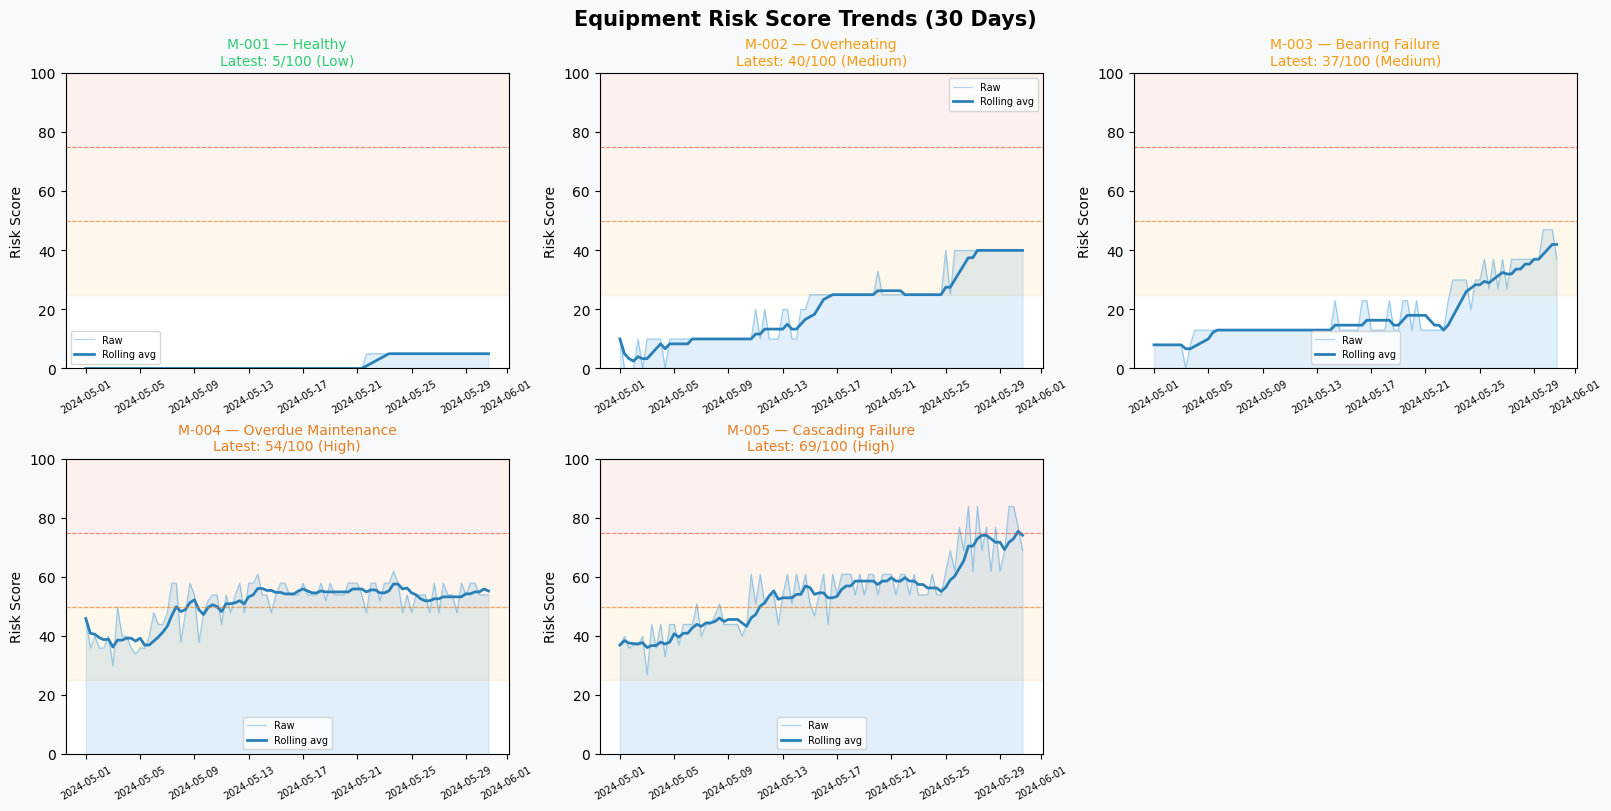

✅ Risk trends chart saved.


In [11]:
# ─────────────────────────────────────────────
# PLOT 1: Risk Score Trends Over Time
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
fig.suptitle('Equipment Risk Score Trends (30 Days)', fontsize=15, fontweight='bold')

for ax, eq_id in zip(axes.flat, EQUIPMENT_IDS):
    sub = df[df['equipment_id'] == eq_id].sort_values('timestamp')
    # Rolling average
    sub = sub.copy()
    sub['rolling'] = sub['risk_score'].rolling(6, min_periods=1).mean()

    ax.fill_between(sub['timestamp'], sub['risk_score'], alpha=0.15, color='#3498db')
    ax.plot(sub['timestamp'], sub['risk_score'], alpha=0.4, linewidth=0.8, color='#3498db', label='Raw')
    ax.plot(sub['timestamp'], sub['rolling'], linewidth=2, color='#2980b9', label='Rolling avg')

    # Risk threshold bands
    ax.axhspan(75, 100, alpha=0.08, color='#e74c3c')
    ax.axhspan(50, 75,  alpha=0.08, color='#e67e22')
    ax.axhspan(25, 50,  alpha=0.08, color='#f39c12')

    ax.axhline(75, color='#e74c3c', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.axhline(50, color='#e67e22', linestyle='--', linewidth=0.8, alpha=0.6)

    latest = sub.iloc[-1]
    ax.set_title(f'{eq_id} — {latest["profile"]}\nLatest: {int(latest["risk_score"])}/100 ({latest["risk_level"]})',
                 fontsize=10, color=RISK_COLORS[latest['risk_level']])
    ax.set_ylim(0, 100)
    ax.set_ylabel('Risk Score')
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.legend(fontsize=7)

axes.flat[-1].set_visible(False)
plt.savefig('data/risk_trends.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Risk trends chart saved.')

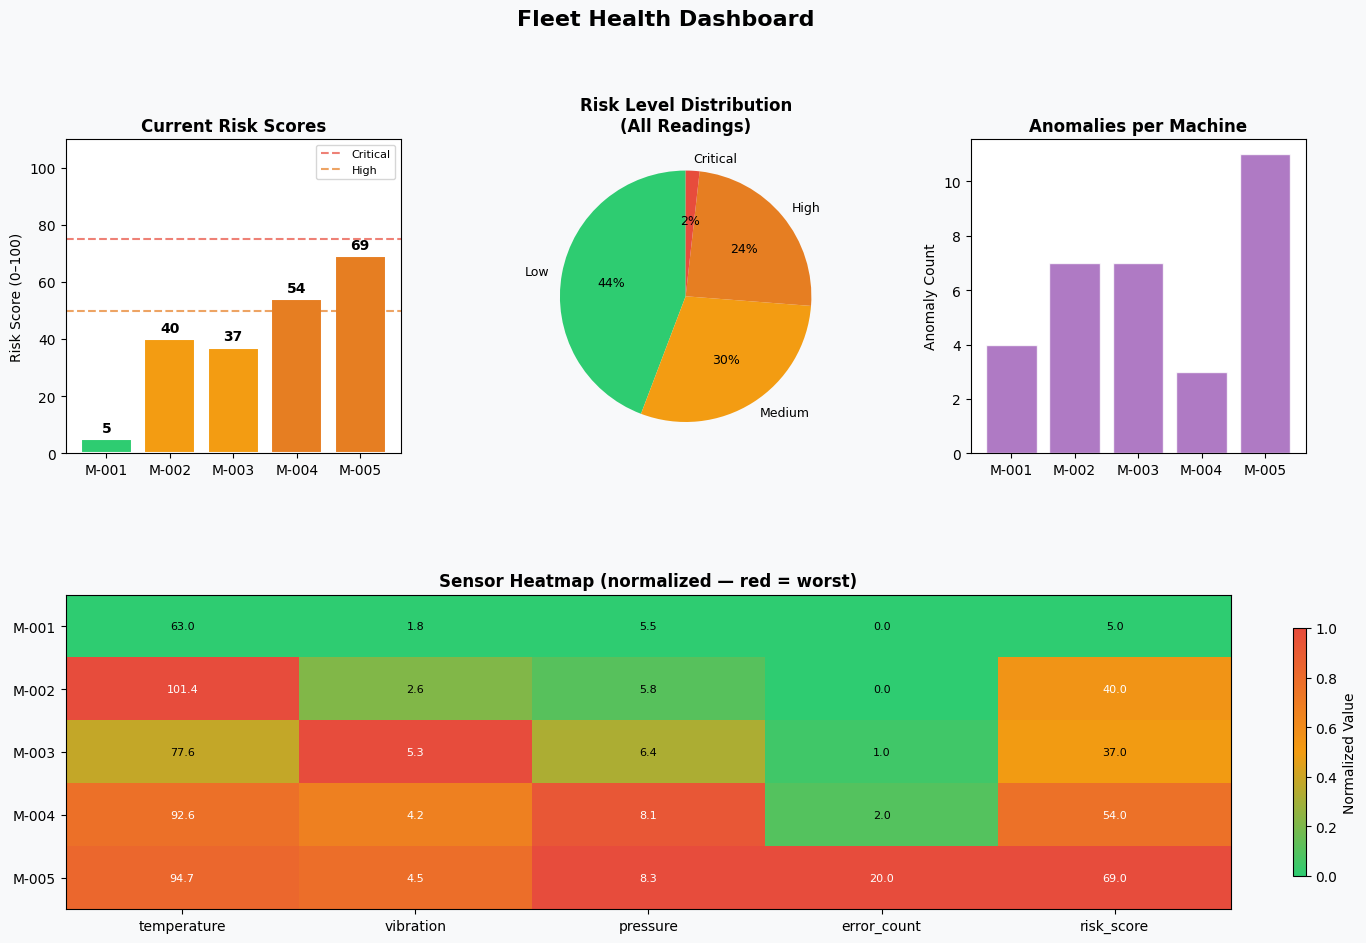

✅ Fleet dashboard saved.


In [12]:
# ─────────────────────────────────────────────
# PLOT 2: Fleet Overview Dashboard
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Fleet Health Dashboard', fontsize=16, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# --- Risk Score Bar Chart ---
ax1 = fig.add_subplot(gs[0, 0])
bar_colors = [RISK_COLORS[r] for r in summary['risk_level']]
bars = ax1.bar(summary['equipment_id'], summary['risk_score'], color=bar_colors, edgecolor='white', linewidth=1.5)
for bar, score in zip(bars, summary['risk_score']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{int(score)}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_title('Current Risk Scores', fontweight='bold')
ax1.set_ylim(0, 110)
ax1.set_ylabel('Risk Score (0–100)')
ax1.axhline(75, color='#e74c3c', linestyle='--', alpha=0.7, label='Critical')
ax1.axhline(50, color='#e67e22', linestyle='--', alpha=0.7, label='High')
ax1.legend(fontsize=8)

# --- Risk Level Pie ---
ax2 = fig.add_subplot(gs[0, 1])
level_counts = df['risk_level'].value_counts()
pie_colors = [RISK_COLORS[l] for l in level_counts.index]
ax2.pie(level_counts.values, labels=level_counts.index, colors=pie_colors,
        autopct='%1.0f%%', startangle=90, textprops={'fontsize': 9})
ax2.set_title('Risk Level Distribution\n(All Readings)', fontweight='bold')

# --- Anomaly Count by Machine ---
ax3 = fig.add_subplot(gs[0, 2])
anomaly_counts = df.groupby('equipment_id')['is_anomaly'].sum()
ax3.bar(anomaly_counts.index, anomaly_counts.values, color='#9b59b6', alpha=0.8, edgecolor='white')
ax3.set_title('Anomalies per Machine', fontweight='bold')
ax3.set_ylabel('Anomaly Count')

# --- Sensor Heatmap ---
ax4 = fig.add_subplot(gs[1, :])
sensor_cols = ['temperature', 'vibration', 'pressure', 'error_count', 'risk_score']
heatmap_data = summary.set_index('equipment_id')[sensor_cols]
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())
cmap = LinearSegmentedColormap.from_list('risk', ['#2ecc71', '#f39c12', '#e74c3c'])
im = ax4.imshow(heatmap_norm.values, aspect='auto', cmap=cmap, vmin=0, vmax=1)
ax4.set_xticks(range(len(sensor_cols)))
ax4.set_xticklabels(sensor_cols, fontsize=10)
ax4.set_yticks(range(len(EQUIPMENT_IDS)))
ax4.set_yticklabels(EQUIPMENT_IDS)
ax4.set_title('Sensor Heatmap (normalized — red = worst)', fontweight='bold')
plt.colorbar(im, ax=ax4, orientation='vertical', fraction=0.01, label='Normalized Value')
for i in range(len(EQUIPMENT_IDS)):
    for j in range(len(sensor_cols)):
        ax4.text(j, i, f'{heatmap_data.values[i, j]:.1f}', ha='center', va='center',
                 fontsize=8, color='white' if heatmap_norm.values[i, j] > 0.5 else 'black')

plt.savefig('data/fleet_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Fleet dashboard saved.')

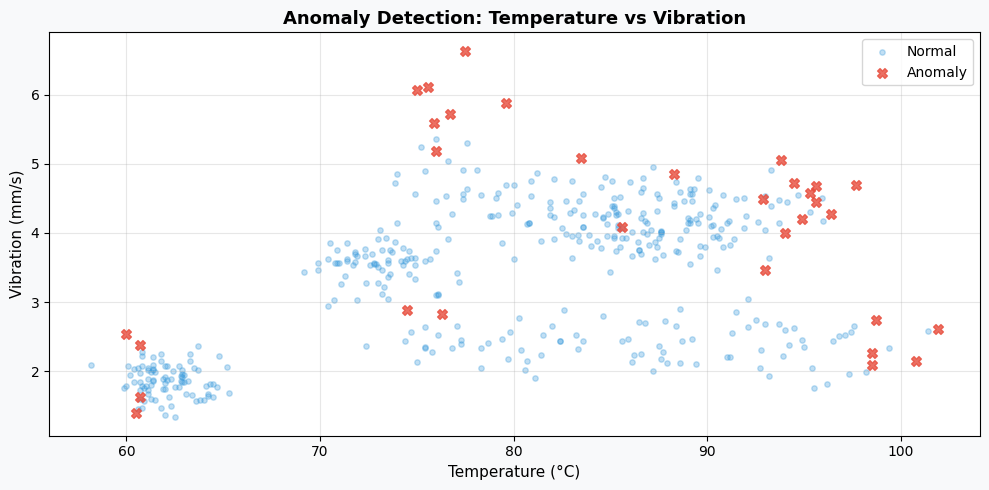

✅ Anomaly scatter plot saved.


In [13]:
# ─────────────────────────────────────────────
# PLOT 3: Anomaly Scatter Plot
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

normal   = df[~df['is_anomaly']]
anomalous = df[df['is_anomaly']]

ax.scatter(normal['temperature'], normal['vibration'],
           c='#3498db', alpha=0.3, s=15, label='Normal')
ax.scatter(anomalous['temperature'], anomalous['vibration'],
           c='#e74c3c', alpha=0.8, s=50, marker='X', label='Anomaly', zorder=5)

ax.set_xlabel('Temperature (°C)', fontsize=11)
ax.set_ylabel('Vibration (mm/s)', fontsize=11)
ax.set_title('Anomaly Detection: Temperature vs Vibration', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.savefig('data/anomaly_scatter.png', dpi=120, bbox_inches='tight')
plt.tight_layout()
plt.show()
print('✅ Anomaly scatter plot saved.')

---
## Section 5 — LLM Suggestion Engine (Offline expert system + optional Claude API)
Turn the risk analysis into a plain-English, 5-point maintenance plan.

By default this runs **fully offline** with a built-in maintenance expert system — **no API key and no internet required**, so it works anywhere in the world. Optionally set `USE_LLM_API = True` with an Anthropic key to use Claude instead.

In [14]:
# ─────────────────────────────────────────────
# RECOMMENDATION ENGINE  (offline expert rules + optional Claude API)
# ─────────────────────────────────────────────
# Default path = OFFLINE expert system: zero network calls, zero API key.
# Optional path = Claude API, used only when USE_LLM_API is True and a real key is set.

def build_prompt(row, decisions):
    """Structured prompt — used only on the optional online Claude path."""
    return f"""You are an expert industrial equipment maintenance engineer.
Analyze the following sensor data and provide a professional maintenance recommendation.

Equipment: {row['equipment_id']}
Risk Score: {int(row['risk_score'])}/100
Risk Level: {row['risk_level']}

Sensor Readings:
- Temperature: {row['temperature']}°C
- Vibration: {row['vibration']} mm/s
- Runtime since last maintenance: {row['runtime_hours']} hours
- Operating Pressure: {row['pressure']} bar
- Errors in last 24 hours: {row['error_count']}

Rule-based flags raised:
{chr(10).join('- ' + d for d in decisions)}

Respond in exactly this format:
1. ROOT CAUSE: (1-2 sentences on what is likely causing elevated risk)
2. IMMEDIATE ACTION: (specific step to take right now)
3. MAINTENANCE PLAN: (recommended schedule and tasks for next 7 days)
4. ESTIMATED DOWNTIME: (if maintenance is required, expected hours)
5. RISK IF IGNORED: (what happens if no action is taken)
"""


# ── Offline maintenance expert knowledge base ────────────────────────────────
_SEV_RANK = {'critical': 0, 'high': 1, 'watch': 2}

def _sensor_findings(row):
    """Inspect raw readings and return [(severity, sensor, explanation), ...]."""
    temp = float(row['temperature']); vib = float(row['vibration'])
    rt   = float(row['runtime_hours']); pr  = float(row['pressure'])
    err  = float(row['error_count'])
    f = []
    if   temp > 95: f.append(('critical', 'temperature', f'Temperature {temp:.0f}°C is critically high (>95°C), indicating a cooling failure or sustained overload.'))
    elif temp > 85: f.append(('high',     'temperature', f'Temperature {temp:.0f}°C is elevated (>85°C), an early overheating trend.'))
    elif temp > 75: f.append(('watch',    'temperature', f'Temperature {temp:.0f}°C is mildly above normal (>75°C).'))
    if   vib > 6.0: f.append(('critical', 'vibration',   f'Vibration {vib:.1f} mm/s is severe (>6.0), a strong bearing-failure or imbalance signature.'))
    elif vib > 4.5: f.append(('high',     'vibration',   f'Vibration {vib:.1f} mm/s is high (>4.5), showing developing mechanical wear.'))
    elif vib > 3.0: f.append(('watch',    'vibration',   f'Vibration {vib:.1f} mm/s is slightly raised (>3.0).'))
    if   rt > 500:  f.append(('high',     'runtime',     f'{rt:.0f} h since last service (>500) — well past the maintenance interval.'))
    elif rt > 350:  f.append(('watch',    'runtime',     f'{rt:.0f} h since last service (>350) — service window approaching.'))
    if   pr > 9.0:  f.append(('high',     'pressure',    f'Pressure {pr:.1f} bar exceeds the safe limit (>9.0).'))
    elif pr > 7.5:  f.append(('watch',    'pressure',    f'Pressure {pr:.1f} bar is slightly high (>7.5).'))
    if   err > 8:   f.append(('high',     'error',       f'{err:.0f} errors/24h (>8) indicate control-system instability.'))
    elif err > 4:   f.append(('watch',    'error',       f'{err:.0f} errors/24h (>4) — a rising fault count.'))
    f.sort(key=lambda x: _SEV_RANK[x[0]])
    return f

_IMMEDIATE = {
    'temperature': 'Reduce load and check the cooling/lubrication system (coolant level, fan, heat exchanger). If the temperature keeps climbing, shut the unit down to prevent thermal damage.',
    'vibration':   'Inspect bearings, couplings and mounting bolts for play or wear. Re-balance the rotor; stop the machine if vibration is in the severe band to avoid catastrophic bearing failure.',
    'runtime':     'Schedule the overdue service now — replace lubricant, filters and any wear parts that are past their interval.',
    'pressure':    'Check for blockages or valve faults, bring pressure back into the safe range, and confirm the relief valve is functioning.',
    'error':       'Pull the controller fault log, clear recoverable faults, and inspect sensors and wiring for intermittent signals.',
    None:          'No immediate action required — continue routine monitoring.',
}

_RISK_IF_IGNORED = {
    'temperature': 'Continued overheating can warp components, break down lubricant, and lead to seizure or even a fire hazard.',
    'vibration':   'Unchecked vibration rapidly destroys bearings and can cause sudden, unplanned shaft or housing failure.',
    'runtime':     'Running past the service interval sharply raises the probability of a wear-related breakdown.',
    'pressure':    'Sustained over-pressure risks seal rupture, leaks, or hose/line failure.',
    'error':       'A rising error rate often precedes a controller or sensor failure that can halt the whole line.',
    None:          'Risk stays low; no significant short-term consequence is expected.',
}

_PLAN = {
    'Critical': 'Day 0: take the machine offline for inspection. Days 1-2: replace the failing component identified above. Days 3-7: run-in test and confirm every sensor returns to baseline before resuming full production.',
    'High':     'Days 1-2: schedule a planned inspection at the next shift change. Days 3-5: replace worn parts and re-lubricate. Days 6-7: re-measure and confirm the risk score falls below 25.',
    'Medium':   'Within 7 days: perform standard preventive maintenance (lubrication, cleaning, fastener and sensor check) and re-baseline the flagged reading.',
    'Low':      'No special action — keep the routine 30-day preventive-maintenance cycle.',
}

_DOWNTIME = {
    'Critical': '8-24 hours (component replacement plus run-in test).',
    'High':     '2-6 hours (planned inspection and parts replacement).',
    'Medium':   '0.5-2 hours (routine preventive maintenance).',
    'Low':      'None expected.',
}

def generate_offline_recommendation(row, decisions):
    """Built-in expert system: same 5-point structured plan, no API key, no internet."""
    level    = row.get('risk_level', 'Low')
    score    = int(row.get('risk_score', 0))
    findings = _sensor_findings(row)
    primary  = findings[0][1] if findings else None

    if findings:
        root = findings[0][2]
        if len(findings) > 1:
            others = ', '.join(s for _, s, _ in findings[1:])
            root += f' It is compounded by out-of-range {others} readings, suggesting multi-factor degradation.'
    else:
        root = 'All sensors sit within their baseline ranges; no degradation signature is present.'

    rec = (
        f"1. ROOT CAUSE: {root}\n"
        f"2. IMMEDIATE ACTION: {_IMMEDIATE[primary]}\n"
        f"3. MAINTENANCE PLAN: {_PLAN.get(level, _PLAN['Low'])}\n"
        f"4. ESTIMATED DOWNTIME: {_DOWNTIME.get(level, _DOWNTIME['Low'])}\n"
        f"5. RISK IF IGNORED: {_RISK_IF_IGNORED[primary]}\n"
        f"\n— Generated offline by the built-in maintenance expert system "
        f"(risk {score}/100, level {level}; no API key required)."
    )
    return rec


def get_llm_recommendation(row, decisions):
    """Return a 5-point plan. Offline expert system by default; Claude only if enabled."""
    online = USE_LLM_API and anthropic is not None and ANTHROPIC_API_KEY != 'YOUR_API_KEY_HERE'
    if not online:
        return generate_offline_recommendation(row, decisions)
    try:
        client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
        message = client.messages.create(
            model='claude-sonnet-4-6',
            max_tokens=600,
            messages=[{'role': 'user', 'content': build_prompt(row, decisions)}],
        )
        return message.content[0].text
    except Exception as e:
        # Never break the demo — fall back to the offline engine.
        return (generate_offline_recommendation(row, decisions) +
                f"\n\n(Note: Claude API was unavailable, so the offline engine was used. {e})")


_mode = 'ONLINE (Claude)' if (USE_LLM_API and ANTHROPIC_API_KEY != 'YOUR_API_KEY_HERE') else 'OFFLINE expert system'
print('✅ Recommendation engine ready.')
print(f'   Mode: {_mode}')
print('   Offline mode needs no API key and no internet — runs worldwide, including China.')


✅ Recommendation engine ready.
   Mode: OFFLINE expert system
   Offline mode needs no API key and no internet — runs worldwide, including China.


In [15]:
# ─────────────────────────────────────────────
# LLM WIDGET: Select machine → get recommendation
# ─────────────────────────────────────────────
w_llm_machine = widgets.Dropdown(
    options=EQUIPMENT_IDS,
    description='Equipment:',
    style={'description_width': '100px'},
    layout=widgets.Layout(width='280px')
)
w_llm_use_live = widgets.Checkbox(
    value=False, description='Use live reading from Section 2',
    style={'description_width': '220px'}
)
btn_llm  = widgets.Button(description='🤖 Get Maintenance Recommendation', button_style='success',
                           layout=widgets.Layout(width='240px'))
out_llm  = widgets.Output()


def on_llm_click(b):
    with out_llm:
        clear_output()
        print('⏳ Analyzing equipment and generating recommendation...')

    if w_llm_use_live.value and live_reading:
        row = pd.Series(live_reading)
    else:
        row = summary[summary['equipment_id'] == w_llm_machine.value].iloc[0]

    decisions = generate_decision(row)
    recommendation = get_llm_recommendation(row, decisions)

    with out_llm:
        clear_output()
        color = RISK_COLORS.get(row.get('risk_level', 'Low'), '#ccc')
        display(HTML(f"""
        <div style="border-left:5px solid {color}; padding:12px 16px; background:#fafafa;
                    border-radius:4px; font-family:sans-serif; line-height:1.7;">
            <h4 style="margin:0 0 8px">🤖 AI Maintenance Recommendation — {row['equipment_id']}
            <span style="color:{color};">({row['risk_level']})</span></h4>
            <pre style="white-space:pre-wrap; font-family:monospace; font-size:13px;">{recommendation}</pre>
        </div>
        """))


btn_llm.on_click(on_llm_click)

display(widgets.VBox([
    widgets.HTML('<h3 style="margin:0 0 8px">🤖 LLM Maintenance Advisor</h3>'),
    w_llm_machine,
    w_llm_use_live,
    btn_llm,
    out_llm
]))

In [16]:
# ─────────────────────────────────────────────
# BATCH: Generate recommendations for all Critical/High machines
# ─────────────────────────────────────────────
btn_batch = widgets.Button(description='📋 Batch: All High/Critical Machines',
                            button_style='warning',
                            layout=widgets.Layout(width='300px'))
out_batch = widgets.Output()

def on_batch(b):
    urgent = summary[summary['risk_level'].isin(['High', 'Critical'])]
    with out_batch:
        clear_output()
        if len(urgent) == 0:
            print('✅ No High or Critical machines at this time.')
            return
        print(f'⏳ Generating recommendations for {len(urgent)} machine(s)...\n')
        for _, row in urgent.iterrows():
            decisions = generate_decision(row)
            rec = get_llm_recommendation(row, decisions)
            color = RISK_COLORS[row['risk_level']]
            display(HTML(f"""
            <div style="border-left:5px solid {color}; padding:10px 14px; margin:8px 0;
                        background:#fafafa; border-radius:4px;">
                <h4 style="margin:0 0 6px; color:{color};">{row['equipment_id']} — {row['risk_level']} ({int(row['risk_score'])}/100)</h4>
                <pre style="white-space:pre-wrap; font-size:12px; font-family:monospace;">{rec}</pre>
            </div>
            """))

btn_batch.on_click(on_batch)
display(widgets.VBox([btn_batch, out_batch]))

**Static preview** (below) — prints the offline recommendations inline so they are visible on GitHub/nbviewer without clicking the widget buttons above.

In [17]:
# Inline demo: offline maintenance recommendations for every High/Critical machine
urgent = summary[summary['risk_level'].isin(['High', 'Critical'])]
for _, row in urgent.iterrows():
    print('=' * 64)
    print(f"{row['equipment_id']}  —  {row['risk_level']}  ({int(row['risk_score'])}/100)")
    print('=' * 64)
    print(get_llm_recommendation(row, generate_decision(row)))
    print()

M-004  —  High  (54/100)
1. ROOT CAUSE: Temperature 93°C is elevated (>85°C), an early overheating trend. It is compounded by out-of-range runtime, vibration, pressure readings, suggesting multi-factor degradation.
2. IMMEDIATE ACTION: Reduce load and check the cooling/lubrication system (coolant level, fan, heat exchanger). If the temperature keeps climbing, shut the unit down to prevent thermal damage.
3. MAINTENANCE PLAN: Days 1-2: schedule a planned inspection at the next shift change. Days 3-5: replace worn parts and re-lubricate. Days 6-7: re-measure and confirm the risk score falls below 25.
4. ESTIMATED DOWNTIME: 2-6 hours (planned inspection and parts replacement).
5. RISK IF IGNORED: Continued overheating can warp components, break down lubricant, and lead to seizure or even a fire hazard.

— Generated offline by the built-in maintenance expert system (risk 54/100, level High; no API key required).

M-005  —  High  (69/100)
1. ROOT CAUSE: Temperature 95°C is elevated (>85°C),

---
## Section 6 — Parameter Interaction Dashboard
Explore data interactively: select machine, date range, and adjust risk thresholds.

In [18]:
# ─────────────────────────────────────────────
# INTERACTIVE EXPLORATION DASHBOARD
# ─────────────────────────────────────────────
w_eq = widgets.SelectMultiple(
    options=EQUIPMENT_IDS, value=EQUIPMENT_IDS,
    description='Machines:', rows=5,
    style={'description_width': '80px'},
    layout=widgets.Layout(width='200px')
)
w_metric = widgets.Dropdown(
    options=['risk_score', 'temperature', 'vibration', 'runtime_hours', 'pressure', 'error_count'],
    value='risk_score', description='Metric:',
    style={'description_width': '80px'}, layout=widgets.Layout(width='280px')
)
w_days = widgets.IntRangeSlider(
    value=[0, 30], min=0, max=30, step=1,
    description='Day range:', style={'description_width': '100px'},
    layout=widgets.Layout(width='380px')
)
w_thresh_critical = widgets.IntSlider(
    value=75, min=50, max=95, step=5,
    description='Critical ≥:', style={'description_width': '100px'},
    layout=widgets.Layout(width='320px')
)
w_thresh_high = widgets.IntSlider(
    value=50, min=25, max=74, step=5,
    description='High ≥:', style={'description_width': '100px'},
    layout=widgets.Layout(width='320px')
)
btn_explore = widgets.Button(description='🔄 Update Chart',
                              button_style='primary',
                              layout=widgets.Layout(width='160px'))
out_explore = widgets.Output()


def on_explore(b):
    selected_ids   = list(w_eq.value)
    metric         = w_metric.value
    day_min, day_max = w_days.value
    thresh_critical = w_thresh_critical.value
    thresh_high     = w_thresh_high.value

    start = df['timestamp'].min() + pd.Timedelta(days=day_min)
    end   = df['timestamp'].min() + pd.Timedelta(days=day_max)
    filtered = df[(df['equipment_id'].isin(selected_ids)) &
                  (df['timestamp'] >= start) &
                  (df['timestamp'] <= end)]

    with out_explore:
        clear_output()
        if filtered.empty:
            print('⚠️  No data for selected filters.')
            return

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        fig.suptitle(f'Interactive Dashboard — {metric}  |  Days {day_min}–{day_max}',
                     fontsize=13, fontweight='bold')

        # Line chart
        for eq_id in selected_ids:
            sub = filtered[filtered['equipment_id'] == eq_id].sort_values('timestamp')
            ax1.plot(sub['timestamp'], sub[metric], label=eq_id, linewidth=2)

        if metric == 'risk_score':
            ax1.axhline(thresh_critical, color='#e74c3c', linestyle='--', alpha=0.7, label=f'Critical ({thresh_critical})')
            ax1.axhline(thresh_high,     color='#e67e22', linestyle='--', alpha=0.7, label=f'High ({thresh_high})')

        ax1.set_ylabel(metric)
        ax1.set_title('Trend Over Selected Period')
        ax1.legend(fontsize=8)
        ax1.tick_params(axis='x', rotation=30)
        ax1.grid(True, alpha=0.3)

        # Box plot comparison
        plot_data = [filtered[filtered['equipment_id'] == eq_id][metric].values for eq_id in selected_ids]
        bp = ax2.boxplot(plot_data, labels=selected_ids, patch_artist=True, notch=False)
        box_colors = [RISK_COLORS.get(summary[summary['equipment_id'] == eq]['risk_level'].values[0], '#3498db')
                      for eq in selected_ids]
        for patch, color in zip(bp['boxes'], box_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        ax2.set_ylabel(metric)
        ax2.set_title('Distribution per Machine')
        ax2.grid(True, axis='y', alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Summary stats
        stats = filtered.groupby('equipment_id')[metric].agg(['mean','min','max','std']).round(2)
        display(HTML('<b>Summary Statistics:</b>'))
        display(stats)


btn_explore.on_click(on_explore)

controls = widgets.VBox([
    widgets.HTML('<h3 style="margin:0 0 8px">🎛️  Interactive Exploration</h3>'),
    widgets.HBox([w_eq, widgets.VBox([w_metric, w_days, w_thresh_critical, w_thresh_high])]),
    btn_explore
])
display(widgets.VBox([controls, out_explore]))

In [19]:
# ─────────────────────────────────────────────
# WHAT-IF SIMULATOR
# "What if I reduce temperature by 10°C — how does risk change?"
# ─────────────────────────────────────────────
display(HTML('<h3>🔬 What-If Simulator</h3><p>Adjust a parameter and see how risk score would change for each machine.</p>'))

w_param = widgets.Dropdown(
    options=['temperature', 'vibration', 'runtime_hours', 'pressure', 'error_count'],
    value='temperature', description='Parameter:',
    style={'description_width': '100px'}, layout=widgets.Layout(width='280px')
)
w_delta = widgets.FloatSlider(
    value=0, min=-50, max=50, step=1,
    description='Change by:', style={'description_width': '100px'},
    layout=widgets.Layout(width='380px')
)
btn_whatif = widgets.Button(description='⚡ Simulate', button_style='info',
                             layout=widgets.Layout(width='140px'))
out_whatif = widgets.Output()


def on_whatif(b):
    param = w_param.value
    delta = w_delta.value
    rows  = []
    for _, row in summary.iterrows():
        orig_val  = row[param]
        new_val   = max(0, orig_val + delta)
        new_score = compute_risk_score(
            row['temperature']   + (delta if param == 'temperature'   else 0),
            row['vibration']     + (delta if param == 'vibration'     else 0),
            row['runtime_hours'] + (delta if param == 'runtime_hours' else 0),
            row['pressure']      + (delta if param == 'pressure'      else 0),
            max(0, row['error_count'] + (delta if param == 'error_count' else 0))
        )
        rows.append({
            'Equipment':    row['equipment_id'],
            f'{param} (original)': orig_val,
            f'{param} (new)':      round(new_val, 2),
            'Risk Score (original)': int(row['risk_score']),
            'Risk Score (new)':      new_score,
            'Change':                new_score - int(row['risk_score'])
        })

    result_df = pd.DataFrame(rows)

    def highlight_change(val):
        if isinstance(val, (int, float)):
            if val > 0:  return 'color: #e74c3c; font-weight:bold'
            if val < 0:  return 'color: #27ae60; font-weight:bold'
        return ''

    with out_whatif:
        clear_output()
        display(HTML(f'<b>Simulating: {param} {("+" if delta>=0 else "")}{delta}</b>'))
        display(result_df.style.applymap(highlight_change, subset=['Change']))


btn_whatif.on_click(on_whatif)
display(widgets.VBox([w_param, w_delta, btn_whatif, out_whatif]))

---
## ✅ Project Complete

| Section | Status | Functionality |
|---|---|---|
| 1 — Setup & Data | ✅ | 450 simulated readings, risk engine, anomaly detection |
| 2 — Data Input | ✅ | Sliders for live sensor input + CSV upload |
| 3 — Analysis | ✅ | Fleet summary table, rule-based decision engine |
| 4 — Visualization | ✅ | Trend charts, fleet dashboard, heatmap, anomaly scatter |
| 5 — LLM Engine | ✅ | Claude API integration, per-machine & batch recommendations |
| 6 — Interaction | ✅ | Exploration dashboard, what-if simulator |

### Known Limitations & Future Improvements
- Data is simulated; real sensor integration (MQTT, OPC-UA) would improve accuracy
- Risk thresholds are hardcoded; could be learned from historical failure data
- LLM recommendations could be saved to a maintenance log database
- Could add email/Slack alerting for Critical machines

---
## Section 7 — 📊 Presentation Summary
Run this cell **last** to render a slide-ready summary with live KPIs, fleet status table, and talking points.


In [20]:
# ---------------------------------------------------
# SLIDE-READY PRESENTATION SUMMARY
# Run after all other sections are executed.
# ---------------------------------------------------

def make_badge(label, value, color, sub=None):
    sub_html = f'<div style="font-size:10px;opacity:0.75;margin-top:3px;">{sub}</div>' if sub else ''
    return (
        f'<div style="display:inline-block;background:{color};color:white;border-radius:10px;'
        f'padding:16px 24px;margin:6px;text-align:center;min-width:140px;box-shadow:0 2px 8px rgba(0,0,0,0.18);">'
        f'<div style="font-size:30px;font-weight:900;letter-spacing:-1px;">{value}</div>'
        f'<div style="font-size:11px;opacity:0.85;margin-top:4px;text-transform:uppercase;letter-spacing:1px;">{label}</div>'
        f'{sub_html}</div>'
    )

summary_df = fleet_summary(df)
crit_count = (summary_df['risk_level'] == 'Critical').sum()
high_count = (summary_df['risk_level'] == 'High').sum()
anom_total = df['is_anomaly'].sum()
avg_risk   = df['risk_score'].mean()
worst      = summary_df.loc[summary_df['risk_score'].idxmax()]

badges = (
    make_badge('Machines Monitored', len(summary_df),         '#2c3e50', '5 units tracked') +
    make_badge('Total Readings',      len(df),                '#2980b9', '30 days × 3/day') +
    make_badge('Anomalies Detected',  anom_total,             '#8e44ad', 'IsolationForest') +
    make_badge('Critical Machines',   crit_count,             '#c0392b', 'shutdown required') +
    make_badge('High-Risk Machines',  high_count,             '#e67e22', 'action needed') +
    make_badge('Avg Fleet Risk',       f'{avg_risk:.0f}/100', '#e74c3c', 'fleet-wide score')
)

RC = {'Low':'#27ae60','Medium':'#f39c12','High':'#e67e22','Critical':'#c0392b'}

rows_html = ''
for _, row in summary_df.sort_values('risk_score', ascending=False).iterrows():
    color  = RC[row['risk_level']]
    bar_w  = int(row['risk_score'])
    flags  = ' &nbsp;·&nbsp; '.join(generate_decision(row))
    icon   = '🔴' if row['risk_level']=='Critical' else ('🟠' if row['risk_level']=='High' else ('🟡' if row['risk_level']=='Medium' else '🟢'))
    rows_html += (
        f'<tr style="border-bottom:1px solid #f0f0f0;">'
        f'<td style="font-weight:700;padding:10px 14px;font-size:14px;">{icon} {row["equipment_id"]}</td>'
        f'<td style="padding:10px 14px;color:#666;font-size:13px;">{row["profile"]}</td>'
        f'<td style="padding:10px 14px;">'
        f'<div style="background:#e8e8e8;border-radius:6px;width:180px;height:18px;overflow:hidden;margin-bottom:3px;">'
        f'<div style="width:{bar_w}%;height:100%;background:{color};border-radius:6px;transition:width 0.4s;"></div></div>'
        f'<span style="font-size:12px;color:{color};font-weight:700;">{int(row["risk_score"])}/100 — {row["risk_level"]}</span></td>'
        f'<td style="padding:10px 14px;font-size:12px;color:#444;line-height:1.6;">{flags}</td></tr>'
    )

llm_pts = [
    '🏗️ Guided full system architecture: input → scoring → visualization → LLM pipeline',
    '🎛️ Generated ipywidgets UI, matplotlib multi-panel dashboards, and IsolationForest code',
    '🐛 Debugged widget output scoping, rolling average edge cases, heatmap normalization',
    '📋 Produces structured 5-point plan: Root Cause · Immediate Action · Schedule · Downtime · Risk-if-Ignored',
    '🧠 Interprets multi-sensor anomaly patterns beyond what rule-based thresholds can explain',
]
lim_pts = [
    '📡 Data is simulated — production deploys with real MQTT / OPC-UA sensor streams',
    '📐 Risk thresholds are expert-defined — could be auto-learned from historical failure logs',
    '💾 LLM recommendations are not persisted — a maintenance log DB needed for production use',
    '📲 No push alerting — SMS/email notifications for Critical machines would add real value',
]

llm_html = ''.join(f'<li style="margin:6px 0;font-size:13px;">{p}</li>' for p in llm_pts)
lim_html = ''.join(f'<li style="margin:6px 0;font-size:13px;">{p}</li>' for p in lim_pts)

flow_steps = [
    ('📥', 'Data Input', 'Sliders / CSV upload per machine'),
    ('⚙️', 'Risk Engine', 'Rule-based scoring 0–100 across 5 sensors'),
    ('🤖', 'Anomaly ML', 'IsolationForest flags outlier readings'),
    ('📊', 'Visualize', 'Trends, heatmap, scatter, dashboard'),
    ('💡', 'LLM Advisor', 'Claude generates plain-English action plan'),
    ('🎛️', 'Interact', 'What-if simulator + threshold explorer'),
]
flow_html = ''.join(
    f'<div style="display:inline-block;text-align:center;margin:0 6px;">'
    f'<div style="font-size:28px;">{ic}</div>'
    f'<div style="font-size:12px;font-weight:700;color:#2c3e50;margin-top:4px;">{title}</div>'
    f'<div style="font-size:10px;color:#888;max-width:90px;margin-top:2px;line-height:1.4;">{desc}</div>'
    f'</div>'
    + (f'<div style="display:inline-block;font-size:22px;color:#bbb;vertical-align:top;margin-top:16px;">→</div>' if ic != '🎛️' else '')
    for ic, title, desc in flow_steps
)

display(HTML(
    '<div style="font-family:-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;max-width:1000px;margin:auto;padding:10px;">'

    # ── Header banner
    '<div style="background:linear-gradient(135deg,#1a252f 0%,#2c3e50 60%,#34495e 100%);'
    'color:white;border-radius:14px;padding:32px 36px;margin-bottom:20px;'
    'box-shadow:0 4px 20px rgba(0,0,0,0.25);">'
    '<div style="font-size:11px;letter-spacing:4px;opacity:0.5;text-transform:uppercase;margin-bottom:6px;">'
    'Knowledge Engineering &nbsp;·&nbsp; Final Project &nbsp;·&nbsp; Master\'s Program</div>'
    '<h1 style="margin:0 0 8px;font-size:30px;font-weight:900;">🔧 Equipment Maintenance Decision System</h1>'
    '<p style="margin:0 0 10px;opacity:0.8;font-size:15px;line-height:1.6;">'
    'Real-time AI risk scoring + LLM maintenance advisor for industrial equipment</p>'
    '<div style="font-size:12px;opacity:0.55;border-top:1px solid rgba(255,255,255,0.15);padding-top:10px;margin-top:4px;">'
    '⚠️ Problem: Unplanned equipment failures cost manufacturers <b>$260,000+/hour</b> in downtime &nbsp;·&nbsp; '
    '✅ Solution: Predict failures before they happen using AI-powered sensor monitoring'
    '</div></div>'

    # ── KPI badges
    f'<div style="margin-bottom:20px;">'
    f'<h3 style="margin:0 0 12px;color:#2c3e50;font-size:16px;">📈 Key Results</h3>'
    f'<div>{badges}</div></div>'

    # ── System flow
    f'<div style="background:#f8f9fa;border-radius:10px;padding:18px 22px;margin-bottom:20px;">'
    f'<h3 style="margin:0 0 14px;color:#2c3e50;font-size:16px;">🔄 System Flow</h3>'
    f'<div style="display:flex;flex-wrap:wrap;align-items:flex-start;gap:4px;">{flow_html}</div>'
    f'</div>'

    # ── Fleet status table
    f'<div style="margin-bottom:20px;">'
    f'<h3 style="margin:0 0 12px;color:#2c3e50;font-size:16px;">🏭 Fleet Status (sorted by risk)</h3>'
    '<table style="width:100%;border-collapse:collapse;font-size:13px;background:white;'
    'border-radius:10px;overflow:hidden;box-shadow:0 2px 10px rgba(0,0,0,0.08);">'
    '<thead><tr style="background:#2c3e50;color:white;font-size:12px;letter-spacing:0.5px;">'
    '<th style="padding:11px 14px;text-align:left;">Machine</th>'
    '<th style="padding:11px 14px;text-align:left;">Profile</th>'
    '<th style="padding:11px 14px;text-align:left;">Risk Score</th>'
    '<th style="padding:11px 14px;text-align:left;">Decision Flags</th>'
    f'</tr></thead><tbody>{rows_html}</tbody></table></div>'

    # ── LLM usage + limitations side by side
    '<div style="display:grid;grid-template-columns:1fr 1fr;gap:16px;margin-bottom:16px;">'
    '<div style="background:#eafaf1;border-radius:10px;padding:16px 20px;">'
    '<h3 style="margin:0 0 10px;color:#1e8449;font-size:15px;">🤖 How LLM Was Used</h3>'
    f'<ul style="margin:0;padding-left:18px;">{llm_html}</ul></div>'
    '<div style="background:#fdf2f8;border-radius:10px;padding:16px 20px;">'
    '<h3 style="margin:0 0 10px;color:#8e44ad;font-size:15px;">⚠️ Limitations & Next Steps</h3>'
    f'<ul style="margin:0;padding-left:18px;">{lim_html}</ul></div>'
    '</div>'

    # ── Tech stack footer
    '<div style="background:#2c3e50;color:white;border-radius:10px;padding:14px 20px;'
    'font-size:12px;display:flex;justify-content:space-between;align-items:center;">'
    '<span style="opacity:0.6;">Tech Stack</span>'
    '<span>Python &nbsp;·&nbsp; Jupyter Notebook &nbsp;·&nbsp; pandas &nbsp;·&nbsp; '
    'matplotlib &nbsp;·&nbsp; scikit-learn &nbsp;·&nbsp; ipywidgets &nbsp;·&nbsp; Anthropic Claude API</span>'
    '</div>'

    '</div>'
))
print("✅ Presentation summary rendered.")


Machine,Profile,Risk Score,Decision Flags
🟠 M-005,Cascading Failure,69/100 — High,🌡️ Check cooling system / reduce load · 🔧 Schedule full maintenance (overdue) · ⚠️ Check pressure relief valves · 💻 Review error logs — possible sensor fault
🟠 M-004,Overdue Maintenance,54/100 — High,🌡️ Check cooling system / reduce load · 🔧 Schedule full maintenance (overdue) · ⚠️ Check pressure relief valves
🟡 M-002,Overheating,40/100 — Medium,🌡️ Check cooling system / reduce load
🟡 M-003,Bearing Failure,37/100 — Medium,📳 Inspect bearings and mounting bolts · 🔧 Schedule full maintenance (overdue)
🟢 M-001,Healthy,5/100 — Low,✅ No immediate action required


✅ Presentation summary rendered.
